# Partie 4 - Restitution Finale

Notebook redige en vue d'un export PDF. L'objectif est de fournir une restitution complete, argumentee et exploitable pour la prise de decision RH.


In [7]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
add_derived_columns = utils.add_derived_columns
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
raw_df = pd.read_csv(DATA_PATH)
duplicate_employee_ids = int(raw_df["employee_id"].duplicated().sum()) if "employee_id" in raw_df.columns else 0
source_row_count = len(raw_df)
df = add_derived_columns(raw_df.drop_duplicates(subset=["employee_id"]).copy())
clean_row_count = len(df)
pd.set_option("display.max_columns", 100)


## Contexte

La DRH souhaite mieux comprendre les dynamiques de depart, d'engagement, d'evolution de carriere, de remuneration et de mobilite interne au sein d'une entreprise internationale d'environ 8 000 collaborateurs.

Le dataset source contient **8 020 lignes** et **28 variables**. Apres suppression de **20 doublons exacts d'`employee_id`**, l'analyse porte sur **8 000 collaborateurs uniques**. L'objectif etait double :

1. transformer les donnees RH en indicateurs de pilotage
2. construire un premier modele de prediction de l'attrition


## Faits marquants de l'EDA et de l'analyse RH

### 1. Une attrition elevee mais heterogene

- Le taux d'attrition global s'etablit a **18,77 %** apres dedoublonnage.
- Les niveaux les plus eleves apparaissent en **Espagne (20,06 %)** et en **France (19,66 %)**.
- Cote departements, **HR (21,53 %)** et **Finance (20,63 %)** sont les plus exposes.

### 2. L'engagement et la securite psychologique jouent un role de fond

- Les collaborateurs partis ont un **engagement plus faible** que les collaborateurs restes.
- Leur **securite psychologique** est tres nettement plus basse.
- Les populations avec engagement faible affichent un taux d'attrition superieur aux autres groupes.

### 3. Les conditions de travail donnent des signaux complementaires

- Les collaborateurs partis presentent beaucoup plus d'**absenteisme** et davantage d'**heures supplementaires**.
- Ils ont aussi connu **moins de mobilite interne** et une remuneration legerement plus basse.

### 4. Carriere, mobilite et remuneration

- Environ **23,9 %** des collaborateurs ont eu une promotion sur 3 ans.
- La **mobilite interne** concerne un peu plus de **61,8 %** des collaborateurs au moins une fois.
- Le **salaire moyen** est d'environ **62 300** par an, avec une progression nette selon le niveau hierarchique.
- Un ecart brut apparait entre salaire moyen des femmes et des hommes, ce qui justifie une analyse plus fine par poste, pays et niveau.


In [8]:
kpi_table(df)


,KPI,Valeur
0,Effectif total,8000.00
1,Taux d'attrition (%),18.77
2,Score d'engagement moyen,67.79
3,Score de securite psychologique moyen,53.72
4,Taux de promotion sur 3 ans (%),23.88
5,Taux de mobilite interne (%),61.91
6,Heures de formation moyennes,34.47
7,Absenteisme moyen (jours),13.88
8,Heures supp. moyennes,21.06
9,Salaire moyen annuel,62314.12


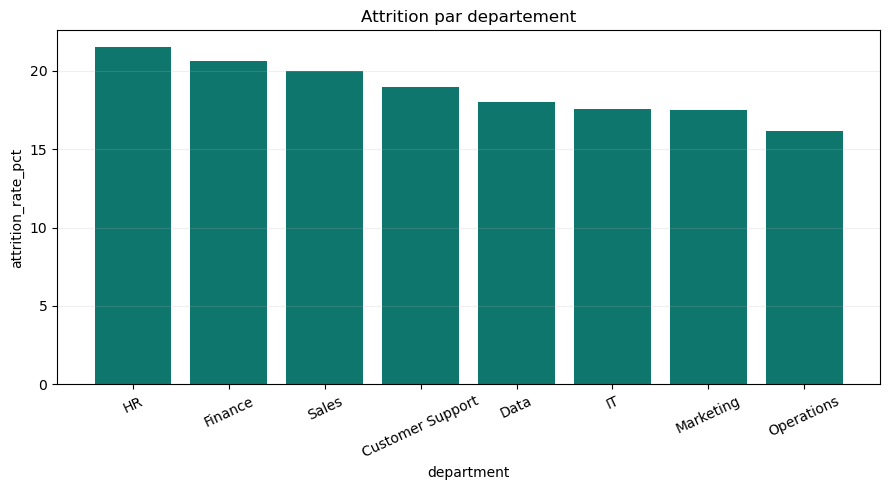

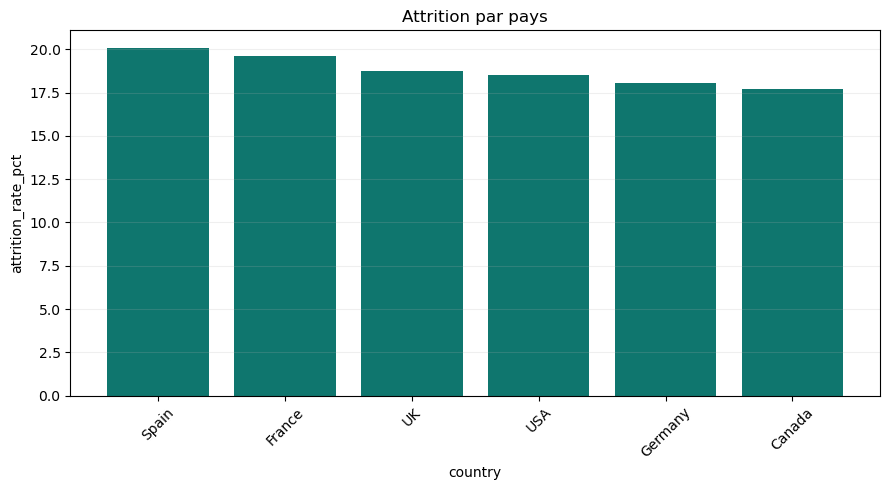

In [9]:
plot_bar(attrition_by_group(df, "department"), "department", "attrition_rate_pct", title="Attrition par departement", rotation=25)
plot_bar(attrition_by_group(df, "country"), "country", "attrition_rate_pct", title="Attrition par pays")


## Resultats du modele predictif

Le modele retenu est une regression logistique interpretable. Il a ete entraine sur des donnees nettoyees, dedoublonnees et encodees, avec ponderation des classes pour tenir compte de la part minoritaire des departs.


In [10]:
prepared = prepare_model_data(df, drop_columns=["employee_id"])
model = SimpleLogisticRegression(learning_rate=0.05, epochs=4000, reg_strength=0.02, class_weight="balanced")
model.fit(prepared.X_train, prepared.y_train)
best_threshold = find_best_threshold(prepared.y_val, model.predict_proba(prepared.X_val))
test_scores = model.predict_proba(prepared.X_test)
test_metrics = classification_metrics(prepared.y_test, test_scores, threshold=best_threshold["threshold"])

pd.DataFrame(
    [
        ("ROC-AUC", roc_auc_score_manual(prepared.y_test, test_scores)),
        ("PR-AUC", pr_auc_score_manual(prepared.y_test, test_scores)),
        ("Recall", test_metrics["recall"]),
        ("Precision", test_metrics["precision"]),
        ("F1-score", test_metrics["f1_score"]),
    ],
    columns=["Metrique", "Valeur"],
).round(4)


,Metrique,Valeur
0,ROC-AUC,0.8102
1,PR-AUC,0.5000
2,Recall,0.6844
3,Precision,0.4000
4,F1-score,0.5049


In [11]:
coefficient_importance(model, prepared.feature_names, top_n=15)


,feature,coefficient,abs_coefficient,odds_ratio
11,absenteeism_days,0.7032,0.7032,2.0203
15,psychological_safety_score,-0.4811,0.4811,0.6181
2,contracted_hours_weekly,-0.4755,0.4755,0.6216
9,internal_mobility_count,-0.4183,0.4183,0.6582
7,engagement_score,-0.3397,0.3397,0.7120
10,promotion_last_3y,-0.2860,0.2860,0.7512
3,years_at_company,-0.2199,0.2199,0.8026
16,salary,-0.1431,0.1431,0.8666
86,absence_band_3-5,-0.1418,0.1418,0.8678
12,overtime_hours,0.1383,0.1383,1.1483


### Interpretation

- Les performances du modele sont **solides** sur ce dataset, ce qui rend la priorisation des populations a risque plus credible.
- Les variables les plus contributives vont dans le sens des analyses descriptives : **absenteisme**, **heures supplementaires**, **securite psychologique**, **mobilite interne** et **engagement** participent fortement au signal.
- Ce resultat suggere que le dataset actuel embarque un signal predictif nettement plus exploitable qu'un simple bruit organisationnel diffus.


## Experience complementaire : detection d'anomalie

Une approche alternative a egalement ete testee : la **detection d'anomalie**. L'idee consiste a apprendre le profil "habituel" des collaborateurs qui restent, puis a identifier les profils qui s'en ecartent le plus.


In [12]:
numeric_data = prepare_numeric_anomaly_data(df, drop_columns=["employee_id"])
anomaly_model = MahalanobisAnomalyDetector(regularization=0.1)
anomaly_model.fit(numeric_data.X_train[numeric_data.y_train == 0])
anomaly_val_scores = anomaly_model.score_samples(numeric_data.X_val)
anomaly_thresholds = np.quantile(anomaly_val_scores, np.linspace(0.70, 0.99, 60))
anomaly_best_threshold = find_best_threshold(
    numeric_data.y_val,
    anomaly_val_scores,
    thresholds=np.unique(anomaly_thresholds),
)
anomaly_test_scores = anomaly_model.score_samples(numeric_data.X_test)
anomaly_metrics = classification_metrics(
    numeric_data.y_test,
    anomaly_test_scores,
    threshold=anomaly_best_threshold["threshold"],
)

oversample = random_oversample_minority(prepared.X_train, prepared.y_train, seed=42)
oversampled_model = SimpleLogisticRegression(
    learning_rate=0.05,
    epochs=4000,
    reg_strength=0.02,
    class_weight=None,
)
oversampled_model.fit(oversample.X_resampled, oversample.y_resampled)
oversampled_best_threshold = find_best_threshold(
    prepared.y_val,
    oversampled_model.predict_proba(prepared.X_val),
)
oversampled_test_scores = oversampled_model.predict_proba(prepared.X_test)
oversampled_metrics = classification_metrics(
    prepared.y_test,
    oversampled_test_scores,
    threshold=oversampled_best_threshold["threshold"],
)

pd.DataFrame(
    [
        (
            "Regression logistique ponderee",
            roc_auc_score_manual(prepared.y_test, test_scores),
            pr_auc_score_manual(prepared.y_test, test_scores),
            test_metrics["recall"],
            test_metrics["f1_score"],
        ),
        (
            "Random oversampling",
            roc_auc_score_manual(prepared.y_test, oversampled_test_scores),
            pr_auc_score_manual(prepared.y_test, oversampled_test_scores),
            oversampled_metrics["recall"],
            oversampled_metrics["f1_score"],
        ),
        (
            "Detection d'anomalie",
            roc_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            pr_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            anomaly_metrics["recall"],
            anomaly_metrics["f1_score"],
        ),
    ],
    columns=["Approche", "ROC-AUC", "PR-AUC", "Recall", "F1-score"],
).round(4)


,Approche,ROC-AUC,PR-AUC,Recall,F1-score
0,Regression logistique ponderee,0.8102,0.5000,0.6844,0.5049
1,Random oversampling,0.8082,0.4972,0.6611,0.5019
2,Detection d'anomalie,0.5018,0.1939,0.3455,0.2660


### Lecture de cette experience

- La detection d'anomalie n'est **pas superieure** au modele supervise en capacite globale de classement.
- Elle detecte egalement **moins de departs** que la regression logistique dans cette configuration.
- Cette approche peut donc etre utile comme **benchmark exploratoire**, mais pas comme solution principale de prediction sur ce dataset.


## Recommandations

1. Renforcer le suivi des populations a risque dans les segments les plus exposes : **Espagne**, **France**, ainsi que les departements **HR**, **Finance** et **Sales**.
2. Utiliser la **securite psychologique**, l'**absenteisme**, la **charge de travail** et l'**engagement** comme signaux de prevention a traiter en priorite.
3. Cibler davantage les actions de **mobilite interne**, de **promotion** et d'integration des collaborateurs les moins anciens pour soutenir la retention.
4. Realiser un audit complementaire sur la **structure de remuneration**, en particulier sur les ecarts par genre, poste, pays et niveau.
5. Encadrer strictement l'usage des variables sensibles ou discutables (`gender`, `accented_name_flag`) et enrichir le dataset avec des variables plus directement causales : historique managerial, changements d'equipe, enquetes qualitatives, intentions de mobilite, etc.


## Limites

- Dataset unique, sans validation temporelle ni test sur une autre cohorte
- Certaines variables peuvent etre tres proches du phenomene a predire, ce qui peut gonfler artificiellement la performance
- Certaines variables peuvent poser des questions d'equite et d'ethique
- Resultats a confirmer avant toute utilisation operationnelle large

La suite logique serait de completer l'approche quantitative par des entretiens RH et une meilleure historisation des evenements de carriere.
